#  Complete EDA (Exploratory Data Analysis) Masterclass — 0 to 100

This notebook walks through **every stage of EDA** end-to-end, with runnable code, using the classic **Titanic** dataset (has numeric, categorical, and missing data — perfect for practicing all EDA techniques).

**Table of Contents**
1. Setup & Loading Data
2. Understanding the Dataset
3. Data Types
4. Shape
5. Descriptive Statistics
6. Missing Value Analysis *(added — critical, always do this early)*
7. Univariate Analysis
8. Bivariate Analysis
9. Multivariate Analysis
10. Correlation Analysis
11. Distribution Analysis (Skewness, Kurtosis, Normality)
12. Outlier Detection
13. Feature-Target Relationship
14. Data Visualization (Recap Gallery)
15. Finding Patterns & Anomalies
16. **Bonus additions you were missing:**
    - Data Cleaning & Missing Value Treatment
    - Categorical Encoding
    - Feature Engineering
    - Multicollinearity Check (VIF)
    - Dimensionality Reduction for Visualization (PCA)
    - Automated EDA Tools (ydata-profiling / Sweetviz)
17. Final EDA Checklist / Summary

> Tip: Run cells top to bottom. Replace the dataset-loading cell with `pd.read_csv('your_file.csv')` to use your own data — everything else will work the same way as long as column names are adjusted.


## 1. Setup & Loading Data

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

%matplotlib inline


In [3]:
# Load dataset (Titanic ships with seaborn -- great for practicing EDA)
df = sns.load_dataset('titanic')
# df = pd.read_csv('your_file.csv')

df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Understanding the Dataset
First contact with data: what columns exist, what do rows look like, how big is it, is there a data dictionary.

In [3]:
df.head()          # first 5 rows


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.tail()           # last 5 rows


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [5]:
df.sample(5)        # random 5 rows (good sanity check, avoids order bias)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
275,1,1,female,63.0,1,0,77.9583,S,First,woman,False,D,Southampton,yes,False
752,0,3,male,33.0,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
541,0,3,female,9.0,4,2,31.2750,S,Third,child,False,NaN,Southampton,no,False
399,1,2,female,28.0,0,0,12.6500,S,Second,woman,False,NaN,Southampton,yes,True
480,0,3,male,9.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False


In [6]:
df.columns.tolist()   # list of column names


['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [7]:
df.info()            # dtypes + non-null counts + memory usage in one shot


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [8]:
df.nunique()         # number of unique values per column (spot IDs vs categories)


survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

## 3. Data Types
Knowing dtypes tells you which EDA techniques apply (numeric -> histograms/correlation, categorical -> count plots, etc.)

In [9]:
df.dtypes


survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

In [11]:
# Split columns by type for later reuse
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_61645/3392290371.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


In [12]:
# Fix wrong dtypes if needed, e.g. a numeric-looking categorical
df['pclass'] = df['pclass'].astype('category')
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(cat_cols)


['pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_61645/2109549851.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


## 4. Shape

In [12]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.shape


Rows: 891
Columns: 15


(891, 15)

In [13]:
df.duplicated().sum()   # count of fully duplicated rows


np.int64(107)

## 5. Descriptive Statistics


Descriptive statistics summarize a column with a handful of numbers instead of forcing you to look at every row. They fall into three groups:

**1. Measures of central tendency** — "where is the data centered?"
- **Mean**: sum of values / count. Sensitive to outliers (a single huge value pulls it a lot).
- **Median**: the middle value when sorted. Robust to outliers — prefer this for skewed data (e.g. income, fare).
- **Mode**: the most frequent value. Mainly useful for categorical data, or numeric data with repeated discrete values.

**2. Measures of spread/dispersion** — "how much does the data vary?"
- **Range** = max − min. Very sensitive to outliers.
- **Variance** = average squared distance from the mean. Units are squared, so hard to interpret directly.
- **Standard deviation (std)** = √variance. Same units as the data — the go-to spread measure.
- **IQR (Interquartile Range)** = Q3 − Q1 (75th percentile − 25th percentile). Robust to outliers, pairs naturally with the median.

**3. Measures of shape** (covered in depth in Section 11)
- Skewness (asymmetry) and kurtosis (tailedness).

**Rule of thumb:** if `mean ≈ median`, the distribution is roughly symmetric. If `mean >> median`, it's right-skewed (long tail of large values, like `fare`). If `mean << median`, it's left-skewed.


In [14]:
df.describe()                      # numeric summary: count, mean, std, min, quartiles, max


,survived,age,sibsp,parch,fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
df.describe(include='object')      # categorical summary: count, unique, top, freq


/var/folders/g7/2nb32w4138xgc8snhbpg3crw0000gn/T/ipykernel_38107/1251087261.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')      # categorical summary: count, unique, top, freq


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [16]:
df.describe(include='all').T       # everything together, transposed for readability


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,3.0,3.0,491.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Individual stats
print("Mean age:", df['age'].mean())
print("Median age:", df['age'].median())
print("Mode age:", df['age'].mode()[0])
print("Std dev age:", df['age'].std())
print("Variance age:", df['age'].var())
print("Range age:", df['age'].max() - df['age'].min())
print("IQR age:", df['age'].quantile(0.75) - df['age'].quantile(0.25))


Mean age: 29.69911764705882
Median age: 28.0
Mode age: 24.0
Std dev age: 14.526497332334042
Variance age: 211.01912474630802
Range age: 79.58
IQR age: 17.875


## 6. Missing Value Analysis 


Missing data isn't just an inconvenience — *why* it's missing changes what you should do about it. Statisticians group missingness into three types:

- **MCAR (Missing Completely At Random)**: the missingness has nothing to do with any variable, observed or not (e.g. a sensor randomly drops readings). Safe to drop or impute simply.
- **MAR (Missing At Random)**: missingness depends on *other observed* variables (e.g. older passengers were less likely to report age). Can often be imputed well using those other variables.
- **MNAR (Missing Not At Random)**: missingness depends on the *value itself* (e.g. people with very high incomes refuse to report income). Hardest case — imputation can introduce bias, and the fact that it's missing may itself be informative.

**Common strategies:**
- **Drop rows** — fine if missingness is small (<5%) and roughly random.
- **Drop columns** — if a column is mostly missing (e.g. >60-70%) and not easily recoverable.
- **Impute** — fill with mean/median (numeric), mode (categorical), a constant, or a model-based prediction (KNN imputer, regression).
- **Flag it** — add a binary `was_missing` column before imputing, so the model can still learn from "missingness" as a signal (important if data is MNAR).

Always **quantify missingness before deciding** — a 2% gap and a 70% gap call for very different treatments.


In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}).sort_values('missing_%', ascending=False)


,missing_count,missing_%
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
survived,0,0.00
pclass,0,0.00
sex,0,0.00
sibsp,0,0.00
parch,0,0.00
fare,0,0.00


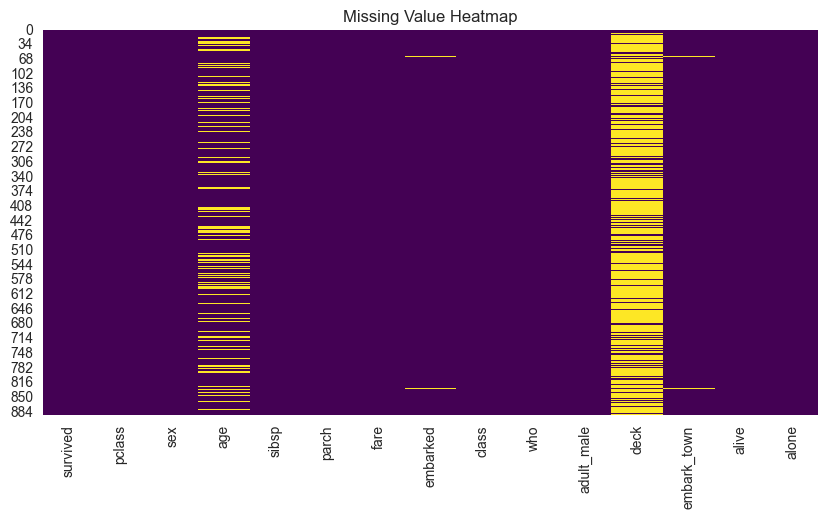

In [6]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()


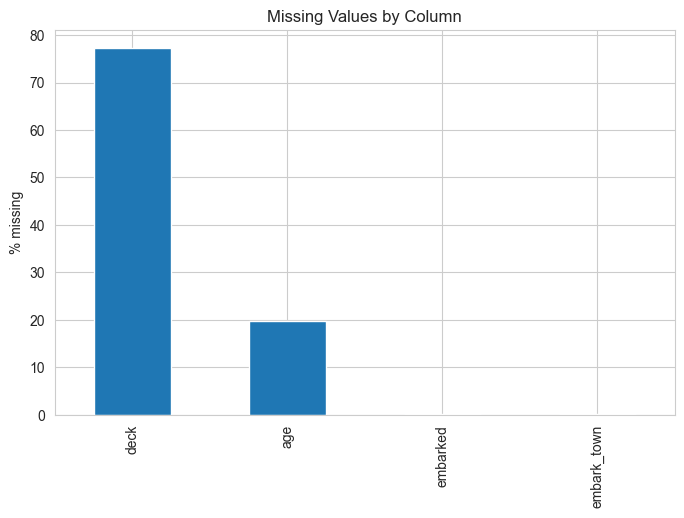

In [7]:
# Bar chart of missing % per column
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar')
plt.ylabel('% missing')
plt.title('Missing Values by Column')
plt.show()


## 7. Univariate Analysis

"Uni" = one. You look at a single variable in isolation to understand its distribution, central tendency, spread, and any obvious irregularities — before you start relating it to anything else.

**For numerical variables:**
- **Histogram**: bins the range of values and counts how many observations fall in each bin. Reveals shape (symmetric, skewed, bimodal).
- **KDE (Kernel Density Estimate)**: a smoothed, continuous version of a histogram — easier to read the overall shape without being distracted by bin-width choices.
- **Boxplot**: shows median, Q1, Q3, whiskers (typically 1.5×IQR), and outlier points beyond the whiskers — a compact 5-number summary view.

**For categorical variables:**
- **Value counts / frequency table**: how many rows fall into each category.
- **Count plot / bar chart**: the visual version of value counts. Watch for class imbalance (e.g. 90% one category, 10% another) — this matters a lot for later modelling.

**What to look for:** Is the distribution symmetric or skewed? Are there multiple peaks (bimodal — could mean two hidden subgroups)? Are any categories rare enough to cause problems later? Are there obvious outliers or impossible values?


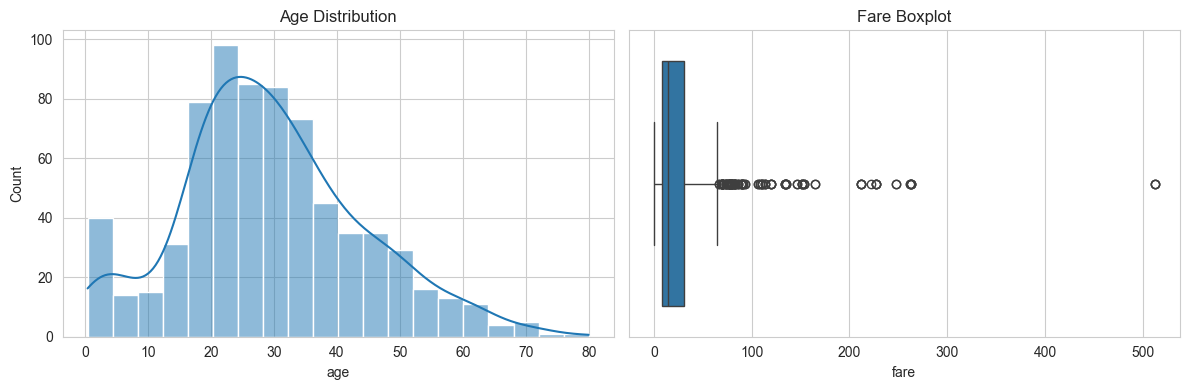

In [8]:
# Numerical: histogram + KDE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.boxplot(x=df['fare'], ax=axes[1])
axes[1].set_title('Fare Boxplot')
plt.tight_layout()
plt.show()


sex
male      577
female    314
Name: count, dtype: int64


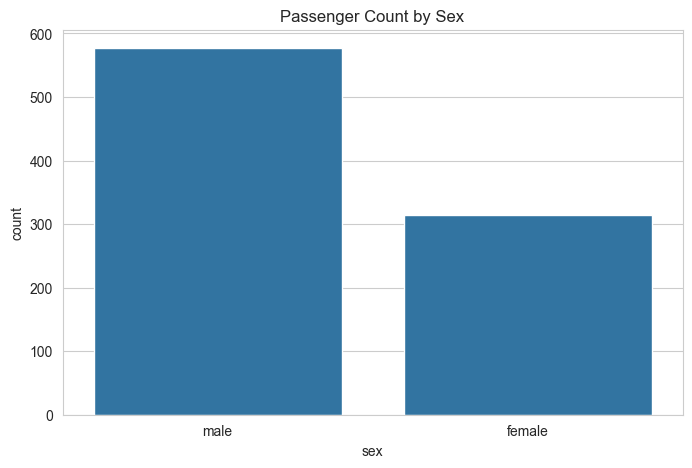

In [9]:
# Categorical: count plot + value counts
print(df['sex'].value_counts())
sns.countplot(x='sex', data=df)
plt.title('Passenger Count by Sex')
plt.show()


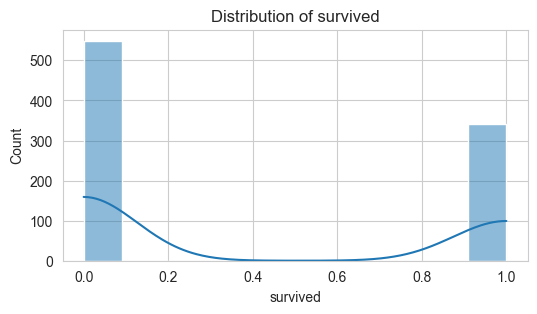

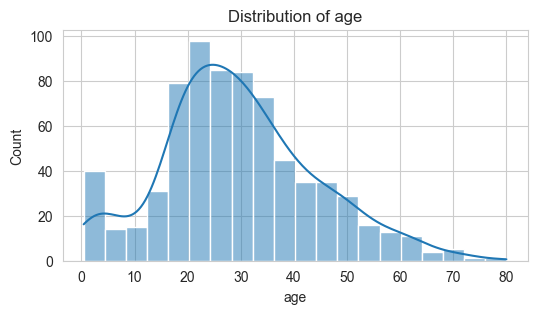

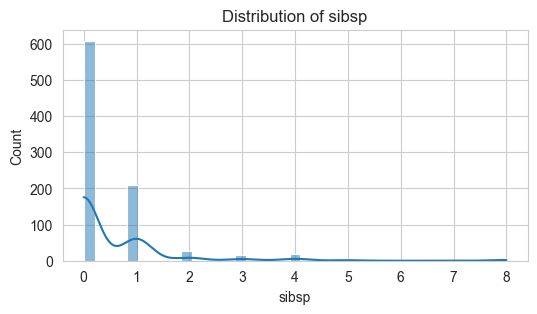

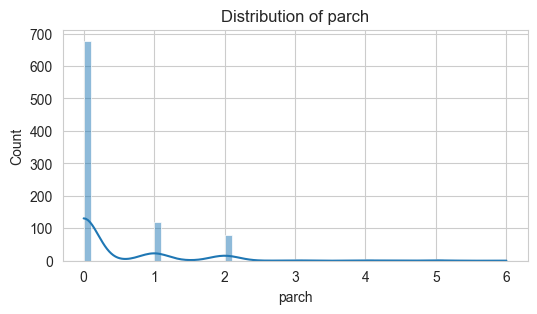

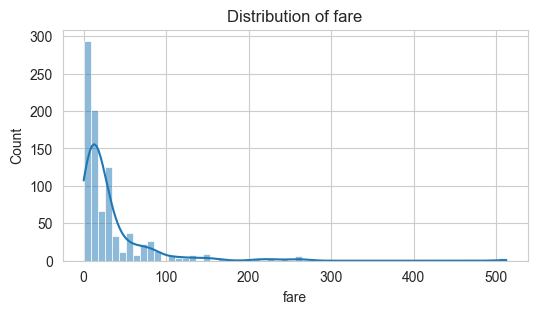

In [13]:
# Loop through all numeric columns quickly
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## 8. Bivariate Analysis

### Theory
"Bi" = two. Now you study how **pairs** of variables relate to each other. The right plot/technique depends on the type of each variable:

| Variable 1 | Variable 2 | Technique |
|---|---|---|
| Numeric | Numeric | Scatter plot, correlation coefficient |
| Numeric | Categorical | Boxplot / violin plot per category, grouped means |
| Categorical | Categorical | Crosstab (contingency table), stacked/grouped bar chart, Chi-square test |

**Scatter plots** reveal the *shape* of a relationship — linear, curved, no relationship, or clusters — which a single correlation number can hide (a famous example: Anscombe's Quartet, where wildly different scatter shapes all give the same correlation coefficient).

**Boxplots/violin plots split by category** let you compare distributions (not just averages) of a numeric variable across groups — e.g. does `age` differ meaningfully by `pclass`?

**Crosstabs** count how often combinations of two categorical values co-occur, and can be normalized (by row/column/total) to see relative patterns rather than raw counts, which is important when group sizes are unequal.


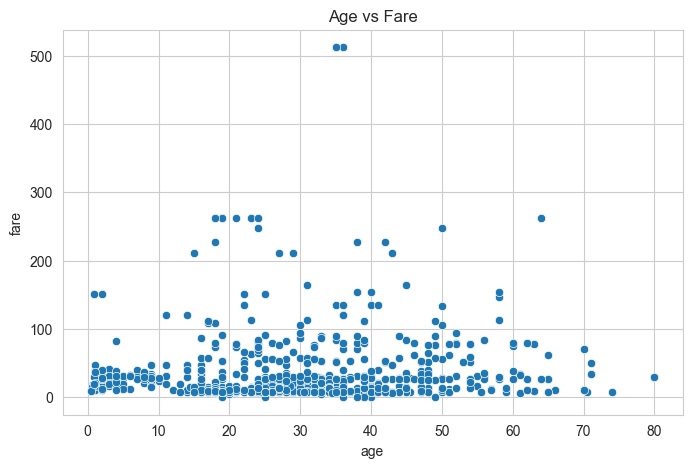

In [14]:
sns.scatterplot(x='age', y='fare', data=df)
plt.title('Age vs Fare')
plt.show()


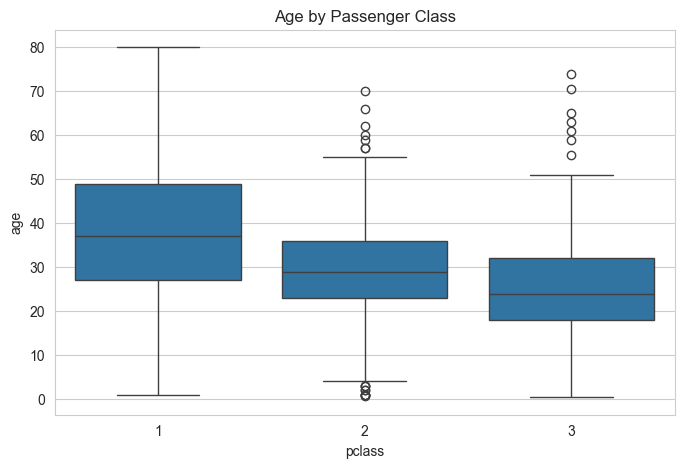

In [15]:
sns.boxplot(x='pclass', y='age', data=df)
plt.title('Age by Passenger Class')
plt.show()


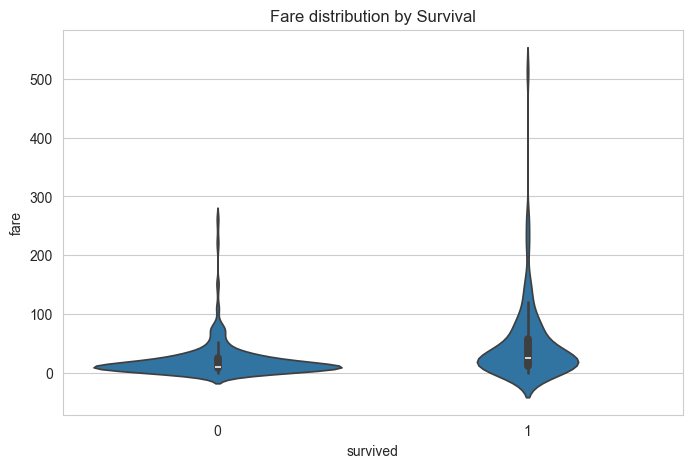

In [16]:
sns.violinplot(x='survived', y='fare', data=df)
plt.title('Fare distribution by Survival')
plt.show()


survived    0    1
pclass            
1          80  136
2          97   87
3         372  119


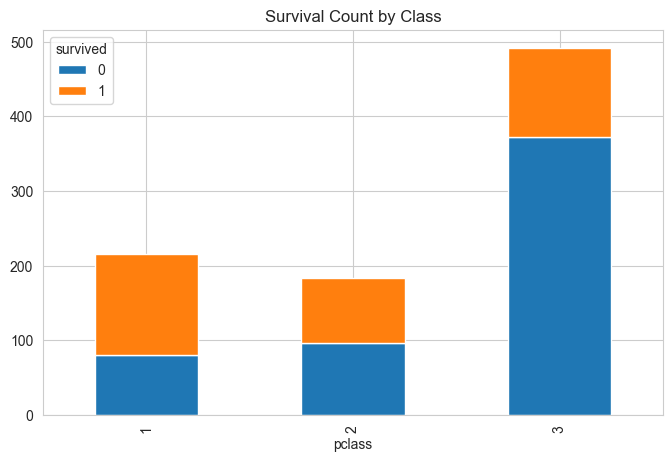

In [17]:
ct = pd.crosstab(df['pclass'], df['survived'])
print(ct)
ct.plot(kind='bar', stacked=True)
plt.title('Survival Count by Class')
plt.show()


## 9. Multivariate Analysis

### Theory
Real-world effects are rarely about just one or two variables — relationships often **interact**. Multivariate analysis studies 3+ variables together to catch patterns that univariate/bivariate views miss.

Example: overall, older passengers may have had a lower survival rate on the Titanic — but that effect might look completely different once you also split by `sex` and `pclass` (e.g. the age effect might only hold for men in 3rd class). This is called an **interaction effect**, and it's invisible unless you look at 3+ variables jointly.

**Common tools:**
- **Pairplot**: a grid of scatter plots for every pair of numeric variables, with histograms on the diagonal — a fast way to eyeball many relationships at once, optionally colored (`hue`) by a categorical/target variable.
- **FacetGrid**: splits the data into a grid of small subplots by one or two categorical variables (rows/columns), so you can compare a distribution or relationship across subgroups side by side.
- **Grouped aggregation** (`groupby` on multiple columns): numeric summary of a variable broken down by combinations of categories.

**Caution:** more variables = more chances to find a "pattern" that's actually just noise (multiple comparisons problem). Treat multivariate patterns as hypotheses to verify, not final conclusions.


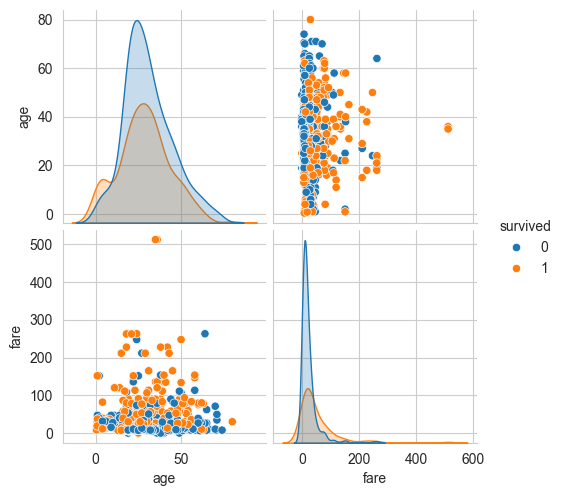

In [18]:
sns.pairplot(df[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived')
plt.show()


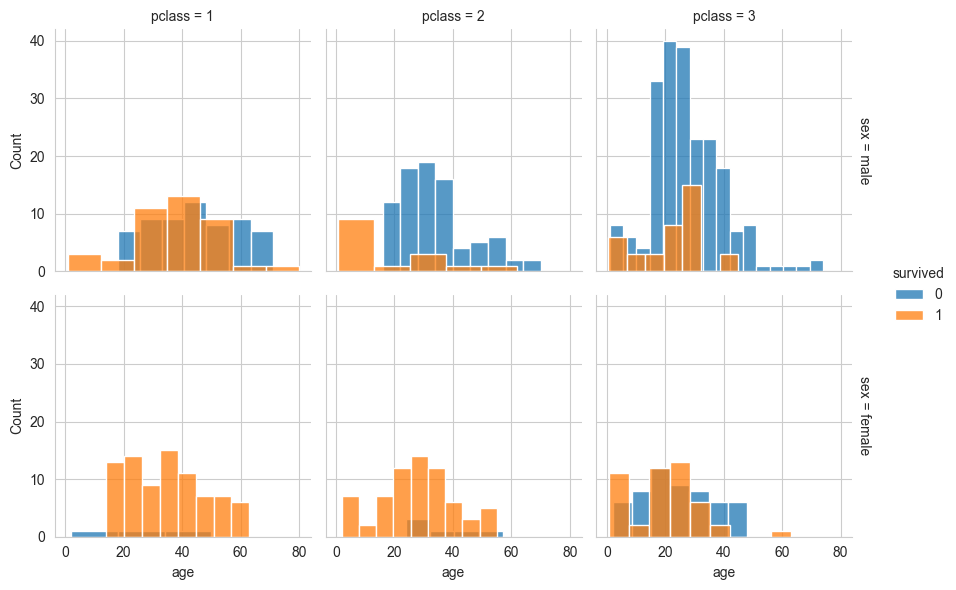

In [19]:
g = sns.FacetGrid(df, col='pclass', row='sex', hue='survived', margin_titles=True)
g.map(sns.histplot, 'age')
g.add_legend()
plt.show()


In [20]:
df.groupby(['pclass', 'sex'])['survived'].mean().unstack()


sex,female,male
pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


## 10. Correlation Analysis

### Theory
Correlation measures how strongly two numeric variables move together, on a scale from **−1 to +1**:
- **+1**: perfect positive relationship (as one goes up, the other goes up proportionally)
- **−1**: perfect negative relationship (as one goes up, the other goes down proportionally)
- **0**: no linear relationship

**Pearson correlation** measures *linear* relationships and is sensitive to outliers. Formula (conceptually): covariance of the two variables, divided by the product of their standard deviations.

**Spearman correlation** measures *monotonic* relationships (does one variable consistently increase/decrease as the other does, even if not in a straight line?) — it works on the *ranks* of the values instead of raw values, so it's more robust to outliers and non-linear-but-monotonic relationships.

**Important caveats:**
- **Correlation ≠ causation.** A strong correlation never proves one variable causes the other — there could be a hidden confounding variable, or reverse causation.
- Correlation near 0 doesn't mean "no relationship" — it means no *linear* (or monotonic, for Spearman) relationship. Two variables can have a strong curved (e.g. U-shaped) relationship with ~0 correlation.
- Always sanity-check a strong correlation with a scatter plot — a couple of extreme outliers can create a fake-looking correlation (or hide a real one).


In [21]:
corr = df[num_cols].corr()          # Pearson by default
corr


,survived,age,sibsp,parch,fare
survived,1.000000,-0.077221,-0.035322,0.081629,0.257307
age,-0.077221,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,0.096067,0.159651,0.216225,1.000000


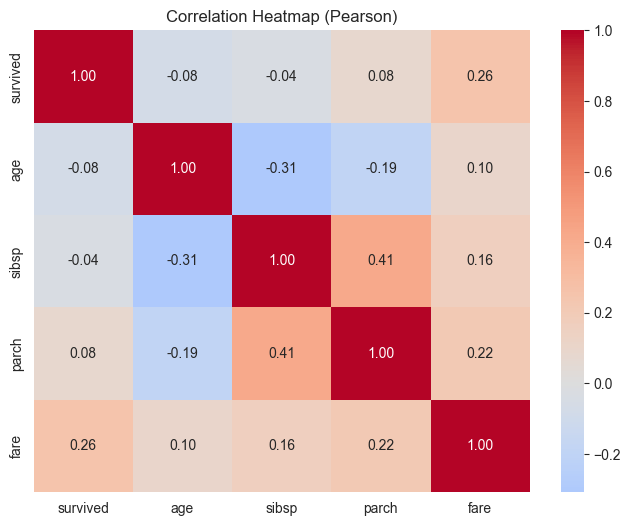

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Heatmap (Pearson)')
plt.show()


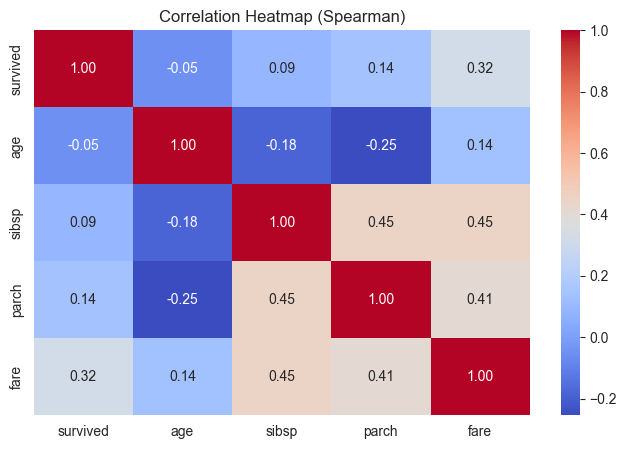

In [23]:
spearman_corr = df[num_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Spearman)')
plt.show()


In [24]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
corr_pairs.head(10)


sibsp     parch       0.414838
fare      survived    0.257307
parch     fare        0.216225
fare      sibsp       0.159651
age       fare        0.096067
parch     survived    0.081629
sibsp     survived   -0.035322
survived  age        -0.077221
age       parch      -0.189119
sibsp     age        -0.308247
dtype: float64

## 11. Distribution Analysis

### Theory
Beyond center and spread, the *shape* of a distribution matters — many statistical methods and ML models assume roughly normal (bell-curve) data, so it's important to check.

**Skewness** measures asymmetry:
- **Skew ≈ 0**: roughly symmetric
- **Skew > 0 (right/positive skew)**: long tail on the right — a few large values pull the mean above the median (classic example: income, fare — most people/tickets are cheap, a few are very expensive)
- **Skew < 0 (left/negative skew)**: long tail on the left

**Kurtosis** measures tailedness (how much of the variance comes from extreme, rare values vs. frequent, moderate deviations):
- **Kurtosis ≈ 0** (using the "excess kurtosis" convention, as pandas' `.kurt()` reports): similar tail-heaviness to a normal distribution
- **Kurtosis > 0**: heavier tails, more outlier-prone than normal
- **Kurtosis < 0**: lighter tails, fewer extreme values than normal

**Why it matters:** highly skewed features often benefit from a transformation (log, sqrt, Box-Cox) before feeding them into linear models, which assume roughly normal, homoscedastic residuals. Tree-based models (Random Forest, XGBoost) are far less sensitive to skew.

**Testing normality:**
- **Shapiro-Wilk test**: null hypothesis is "the data IS normally distributed." A small p-value (typically < 0.05) means you *reject* that — i.e., the data significantly deviates from normal. Works best on small-to-moderate samples.
- **Q-Q (Quantile-Quantile) plot**: plots your data's quantiles against a theoretical normal distribution's quantiles. If the points fall roughly on the diagonal line, the data is close to normal; systematic curves/S-shapes indicate skew or heavy tails.


In [25]:
for col in ['age', 'fare']:
    print(f"{col}: skew={df[col].skew():.2f}, kurtosis={df[col].kurt():.2f}")


age: skew=0.39, kurtosis=0.18
fare: skew=4.79, kurtosis=33.40


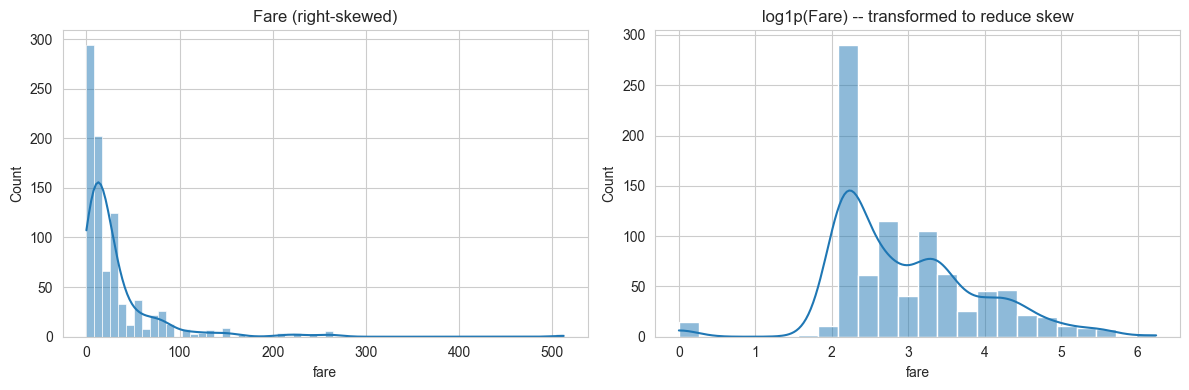

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['fare'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Fare (right-skewed)')
sns.histplot(np.log1p(df['fare'].dropna()), kde=True, ax=axes[1])
axes[1].set_title('log1p(Fare) -- transformed to reduce skew')
plt.tight_layout()
plt.show()


In [27]:
stat, p = stats.shapiro(df['age'].dropna().sample(500, random_state=1))
print(f"Statistic={stat:.3f}, p-value={p:.5f}")


Statistic=0.978, p-value=0.00000


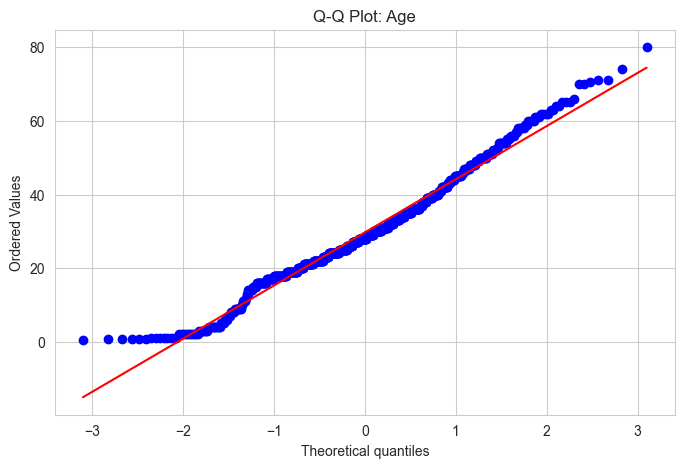

In [28]:
import scipy.stats as st
st.probplot(df['age'].dropna(), dist='norm', plot=plt)
plt.title('Q-Q Plot: Age')
plt.show()


## 12. Outlier Detection

### Theory
An outlier is a data point that differs markedly from the rest. Outliers can be **genuine** (a real billionaire in an income dataset) or **errors** (a typo entering age as 999) — the treatment differs, so always investigate before deleting.

**Univariate methods:**
- **IQR rule**: anything below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged. This is what boxplot whiskers are based on. Robust, doesn't assume normality — the standard default choice.
- **Z-score rule**: anything with `|z| > 3` (i.e., more than 3 standard deviations from the mean) is flagged. Assumes roughly normal data — sensitive to the very outliers it's trying to detect (since they inflate the mean/std), so less robust than IQR for skewed data.

**Multivariate methods:** a point can look "normal" on every individual variable but still be an outlier in combination (e.g. age=5 is normal, fare=500 is normal, but a 5-year-old paying $500 alone might be unusual).
- **Isolation Forest**: an ML model that isolates points via random splits — outliers tend to get isolated in fewer splits than normal points, because they're "different enough" to be easy to separate out.
- Other options: Local Outlier Factor (LOF), DBSCAN clustering, Mahalanobis distance.

**What to do with outliers once found:** investigate first (data entry error? legitimate rare case?). Then: remove, cap/winsorize (clip to a boundary value), transform (log), or leave as-is and use a robust model that isn't sensitive to them. Never silently drop outliers without understanding why they exist — you might be deleting the most interesting rows in your dataset.


In [29]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = df[(df['fare'] < lower) | (df['fare'] > upper)]
print(f"IQR bounds: [{lower:.2f}, {upper:.2f}]")
print("Outliers found:", outliers_iqr.shape[0])


IQR bounds: [-26.72, 65.63]
Outliers found: 116


In [30]:
z_scores = np.abs(stats.zscore(df['fare'].dropna()))
outliers_z = df['fare'].dropna()[z_scores > 3]
print("Outliers found (z-score):", outliers_z.shape[0])


Outliers found (z-score): 20


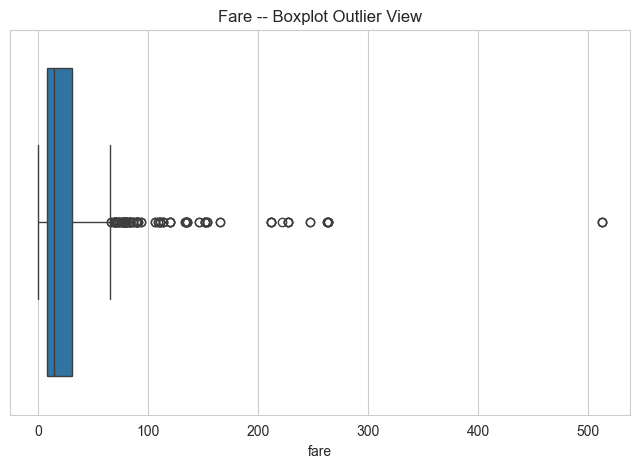

In [31]:
sns.boxplot(x=df['fare'])
plt.title('Fare -- Boxplot Outlier View')
plt.show()


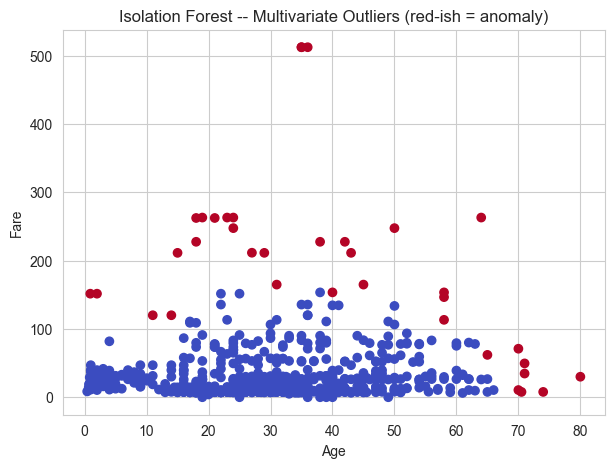

In [32]:
from sklearn.ensemble import IsolationForest

X = df[['age', 'fare']].dropna()
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(X)   # -1 = anomaly, 1 = normal

plt.figure(figsize=(7, 5))
plt.scatter(X['age'], X['fare'], c=(preds == -1), cmap='coolwarm')
plt.xlabel('Age'); plt.ylabel('Fare')
plt.title('Isolation Forest -- Multivariate Outliers (red-ish = anomaly)')
plt.show()


## 13. Feature-Target Relationship

### Theory
If your end goal is to build a predictive model, the single most useful EDA question is: **"which variables actually relate to the target?"** This directly informs feature selection and gives you a sanity-check baseline before modelling ("if `pclass` alone shows a 40-percentage-point survival gap, my model should be picking that up").

**Numeric feature vs. categorical/binary target:**
- Compare the feature's mean/median/distribution across target classes (boxplots, grouped `.mean()`).
- **Point-biserial correlation**: a special case of Pearson correlation when one variable is binary — quantifies the strength of association between a continuous feature and a binary target.

**Categorical feature vs. categorical/binary target:**
- Group-wise rate comparison (e.g. survival rate by `sex`).
- **Chi-square test of independence**: tests whether two categorical variables are statistically associated, or whether any observed difference could plausibly be due to chance.

**Why this matters beyond modelling:** a feature with *zero* relationship to the target is a candidate to drop (reduces noise/overfitting risk); a feature with a *very strong* relationship is worth double-checking for **data leakage** (e.g. a feature that's only known *after* the outcome already happened).


In [ ]:
df.groupby('survived')[num_cols].mean()


In [ ]:
sns.boxplot(x='survived', y='age', data=df)
plt.title('Age vs Survival')
plt.show()


In [ ]:
for col in ['sex', 'pclass', 'embarked']:
    print(df.groupby(col)['survived'].mean(), '\n')


In [ ]:
for col in ['age', 'fare']:
    valid = df[[col, 'survived']].dropna()
    r, p = stats.pointbiserialr(valid['survived'], valid[col])
    print(f"{col}: correlation with survived = {r:.3f} (p={p:.4f})")


## 14. Data Visualization -- Recap Gallery
A cheat-sheet of the plot types most used in EDA, grouped by purpose.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['age'].dropna(), kde=True, ax=axes[0,0]); axes[0,0].set_title('Histogram + KDE')
sns.boxplot(x=df['fare'], ax=axes[0,1]); axes[0,1].set_title('Boxplot')
sns.countplot(x='pclass', data=df, ax=axes[0,2]); axes[0,2].set_title('Count Plot')
sns.scatterplot(x='age', y='fare', hue='survived', data=df, ax=axes[1,0]); axes[1,0].set_title('Scatter Plot')
sns.violinplot(x='pclass', y='age', data=df, ax=axes[1,1]); axes[1,1].set_title('Violin Plot')
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1,2]); axes[1,2].set_title('Heatmap')

plt.tight_layout()
plt.show()


## 15. Finding Patterns & Anomalies

### Theory
This is the "detective work" stage of EDA — actively hunting for structure and irregularities rather than just describing individual variables.

**Patterns** are recurring, meaningful structures in the data:
- **Pivot tables / crosstabs** reveal how an outcome varies across combinations of categories (e.g. survival rate by class *and* sex simultaneously) — patterns that a single groupby might hide.
- **Clustering (e.g. KMeans)** is an *unsupervised* technique that groups similar rows together without being told the "right" answer — useful for discovering natural segments (customer types, passenger profiles) you didn't explicitly look for. KMeans specifically partitions points into *k* groups by minimizing distance to each group's center — you choose *k*, and the "elbow method" (plotting within-cluster variance vs. k) is a common way to pick a good value.

**Anomalies** are irregularities that break the expected pattern — distinct from statistical "outliers" (extreme values) in that anomalies specifically suggest something is *wrong* or *unusual* about the data-generating process: impossible values (negative age), logical inconsistencies (embarked port not in the known list), or sudden unexplained changes.

**Why separate this from outlier detection (Section 12):** outlier detection is about *statistical* extremity in a single or few dimensions; pattern/anomaly finding is broader — it includes logical/domain-knowledge checks (e.g. "fare should never be negative") that no statistical rule alone would catch.


In [33]:
pd.pivot_table(df, values='survived', index='pclass', columns='sex', aggfunc='mean')


sex,female,male
pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [34]:
pd.crosstab(df['embarked'], df['pclass'], normalize='index').round(2)


pclass,1,2,3
embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


In [35]:
print("Negative fares:", (df['fare'] < 0).sum())
print("Age > 100:", (df['age'] > 100).sum())
print("Fare == 0 (possibly free/comp tickets, worth investigating):", (df['fare'] == 0).sum())


Negative fares: 0
Age > 100: 0
Fare == 0 (possibly free/comp tickets, worth investigating): 15


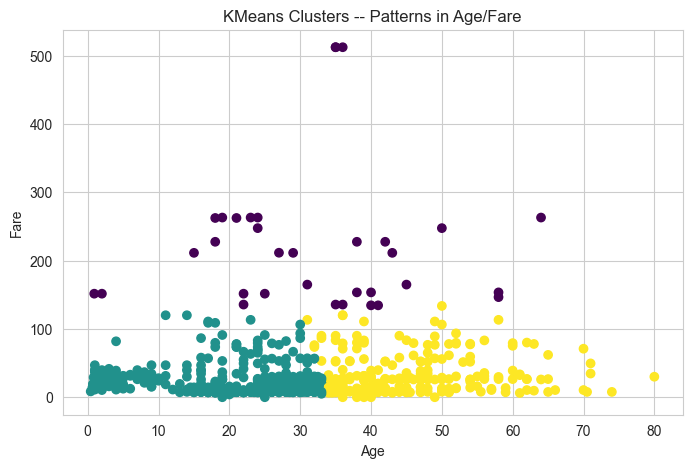

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df[['age', 'fare']].dropna()
scaled = StandardScaler().fit_transform(cluster_data)
km = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = km.fit_predict(scaled)

plt.scatter(cluster_data['age'], cluster_data['fare'], c=labels, cmap='viridis')
plt.xlabel('Age'); plt.ylabel('Fare')
plt.title('KMeans Clusters -- Patterns in Age/Fare')
plt.show()


## 16. Bonus Topics You Were Missing
These aren't always listed under "EDA" explicitly, but any real project needs them.

### 16.1 Data Cleaning & Missing Value Treatment

In [37]:
df_clean = df.copy()

df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

df_clean = df_clean.drop(columns=['deck'])  # too many missing values

df_clean.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

### 16.2 Categorical Encoding

**Theory:** Most ML algorithms need numbers, not text labels, so categorical columns must be converted.
- **Label Encoding**: assigns each category an integer (0, 1, 2, ...). Simple, but implies a false *order/ranking* between categories — fine for tree-based models (which just split on thresholds) or truly ordinal data (e.g. `low < medium < high`), risky for linear/distance-based models on nominal (unordered) categories.
- **One-Hot Encoding**: creates a separate 0/1 column per category. No false ordering, but increases dimensionality — can get unwieldy with high-cardinality columns (e.g. hundreds of cities). `drop_first=True` drops one column to avoid redundancy (the "dummy variable trap") for linear models.
- Other options for high-cardinality data: target encoding, frequency encoding, embeddings (deep learning).

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['sex_encoded'] = le.fit_transform(df_clean['sex'])

df_encoded = pd.get_dummies(df_clean, columns=['embarked'], drop_first=True)
df_encoded.head()


### 16.3 Feature Engineering (common EDA follow-up)

In [ ]:
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0, 12, 18, 35, 60, 100],
                                labels=['child', 'teen', 'young_adult', 'adult', 'senior'])

df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

df_clean[['age', 'age_group', 'family_size']].head()


### 16.4 Multicollinearity Check (VIF)

**Theory:** Multicollinearity is when two or more features are highly correlated *with each other* (not with the target). This is a problem mainly for linear models and statistical inference: it makes coefficient estimates unstable and hard to interpret (the model can't tell which of two correlated features is "responsible" for an effect), though it usually doesn't hurt pure predictive accuracy much.

**VIF (Variance Inflation Factor)** quantifies this for each feature: it's the factor by which a coefficient's variance is inflated due to correlation with other features. VIF = 1 means no correlation with other features; **VIF > 5–10** is the commonly used threshold to flag a problematic feature worth investigating (e.g. dropping one of a correlated pair, or combining them).

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_clean[['age', 'fare', 'family_size']].dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data
# Rule of thumb: VIF > 5-10 indicates problematic multicollinearity


### 16.5 Dimensionality Reduction for Visualization (PCA)

**Theory:** Humans can easily visualize 2-3 dimensions, but real datasets often have dozens of features. **PCA (Principal Component Analysis)** finds new axes (principal components) that are linear combinations of your original features, ordered by how much variance in the data they capture. Projecting onto just the first 2 components lets you visualize high-dimensional structure (clusters, outliers, separability) in a single 2D scatter plot, at the cost of losing some information.

`explained_variance_ratio_` tells you how much of the total variance each component captures — if PC1 + PC2 together explain, say, 85% of the variance, the 2D plot is a fairly faithful summary of the full dataset; if it's only 30%, be cautious about over-interpreting the plot. PCA requires scaling features first (e.g. `StandardScaler`), since it's sensitive to differences in variable scale.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = df_clean[['age', 'fare', 'family_size']].dropna()
scaled = StandardScaler().fit_transform(pca_data)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

plt.scatter(components[:, 0], components[:, 1], alpha=0.6)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA -- 2D projection of numeric features')
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


### 16.6 Automated EDA Tools
Great for a first-pass report, but hand-written EDA (above) is still needed for real insight & feature engineering decisions.
```python
# pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Titanic EDA Report")
profile.to_notebook_iframe()   # or profile.to_file("report.html")

# Alternative: pip install sweetviz
import sweetviz as sv
report = sv.analyze(df)
report.show_html('sweetviz_report.html')
```